# 03 — Exploratory Data Analysis (PySpark + SparkSQL)

## Objective
Understand what drives loan default in Indian retail banking —
using PySpark to analyze 813,692 repayment records across
27,831 approved loans.

## The Core EDA Questions
1. Which applicant characteristics predict default?
2. How does repayment behavior deteriorate before default?
3. What does the DPD trajectory look like pre-NPA?
4. Which loan types and amounts are riskiest?
5. How do CIBIL score and DTI jointly predict default?
6. What is the optimal feature set for modeling?

## Two Levels of Analysis
Level 1 — Static: Applicant profile at time of application
Level 2 — Dynamic: How repayment behavior changes over time

Level 2 is new in this project — similar to driver churn
trajectory analysis but for financial repayment behavior
instead of ride volume.

## Key New Concept: DPD Trajectory
Days Past Due (DPD) is not just a snapshot —
it tells a story over time.
A loan that goes 0→0→0→5→15→30→60→90 DPD
is telling you the default is coming 3 months early.
Detecting this trajectory is the heart of early warning systems.

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DateType, IntegerType
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Resolve the project path robustly regardless of where the notebook is launched from.
current = Path.cwd()
project_dir = next(
    (
        candidate
        for candidate in [current, *current.parents]
        if (candidate / "data" / "processed").exists() and (candidate / "jars").exists()
    ),
    current,
)

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"]        = r"C:\hadoop\bin;" + os.environ["PATH"]

JAR_PATH   = str((project_dir / "jars" / "sqlite-jdbc-3.45.1.0.jar").resolve())
DB_PATH    = str((project_dir / "data" / "loan_default.db").resolve())
DB_URL     = f"jdbc:sqlite:{DB_PATH}"
PROCESSED  = str((project_dir / "data" / "processed").resolve())
LOCAL_TEMP = str((project_dir / "data" / "spark_temp").resolve())

spark = (
    SparkSession.builder
    .appName("LoanDefault_EDA")
    .master("local[2]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.extraClassPath", JAR_PATH)
    .config("spark.executor.extraClassPath", JAR_PATH)
    .config("spark.local.dir", LOCAL_TEMP)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Load cleaned CSVs
profiles  = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/profiles_clean.csv")
loans     = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/loans_clean.csv")
labels    = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/labels_clean.csv")
repayment = spark.read.option("header","true") \
                .option("inferSchema","true") \
                .csv(f"{PROCESSED}/repayment_clean.csv")

# Fix date columns after CSV read
loans = loans.withColumn(
    "application_date",
    F.to_date(F.col("application_date"), "yyyy-MM-dd")
)
repayment = repayment.withColumn(
    "due_date",
    F.to_date(F.col("due_date"), "yyyy-MM-dd")
)

# Register as SQL views
profiles.createOrReplaceTempView("profiles")
loans.createOrReplaceTempView("loans")
labels.createOrReplaceTempView("labels")
repayment.createOrReplaceTempView("repayment")

# Cache repayment — used in every section
repayment.cache()
_ = repayment.count()

print("Data loaded and registered ✅")
print(f"  profiles  : {profiles.count():>8,}")
print(f"  loans     : {loans.count():>8,}")
print(f"  labels    : {labels.count():>8,}")
print(f"  repayment : {repayment.count():>8,} (cached)")
print(f"\nOverall default rate: "
      f"{labels.agg(F.mean('is_defaulted')).collect()[0][0]*100:.2f}%")

Data loaded and registered ✅
  profiles  :   50,000
  loans     :   50,000
  labels    :   27,831
  repayment :  813,692 (cached)

Overall default rate: 7.02%


EDA SECTION 1 — APPLICANT PROFILE vs DEFAULT RATE

Default Rate by CIBIL Band:
+--------------------+-----+----------------+----------+-----------+
|cibil_band          |loans|default_rate_pct|avg_income|avg_dti_pct|
+--------------------+-----+----------------+----------+-----------+
|1. 800+ Excellent   |7939 |2.8             |440184.0  |26.1       |
|2. 750-799 Very Good|3887 |4.35            |439009.0  |25.9       |
|3. 700-749 Good     |6880 |6.57            |429411.0  |26.9       |
|4. 650-699 Fair     |6109 |10.84           |440305.0  |27.5       |
|5. 600-649 Poor     |1622 |11.84           |442701.0  |27.3       |
|6. <600 Very Poor   |1394 |18.51           |435435.0  |27.8       |
+--------------------+-----+----------------+----------+-----------+

Default Rate by DTI Band:
+-------------+-----+----------------+
|dti_band     |loans|default_rate_pct|
+-------------+-----+----------------+
|1. DTI <20%  |10512|4.59            |
|2. DTI 20-35%|7787 |6.34            |
|3. DTI 3

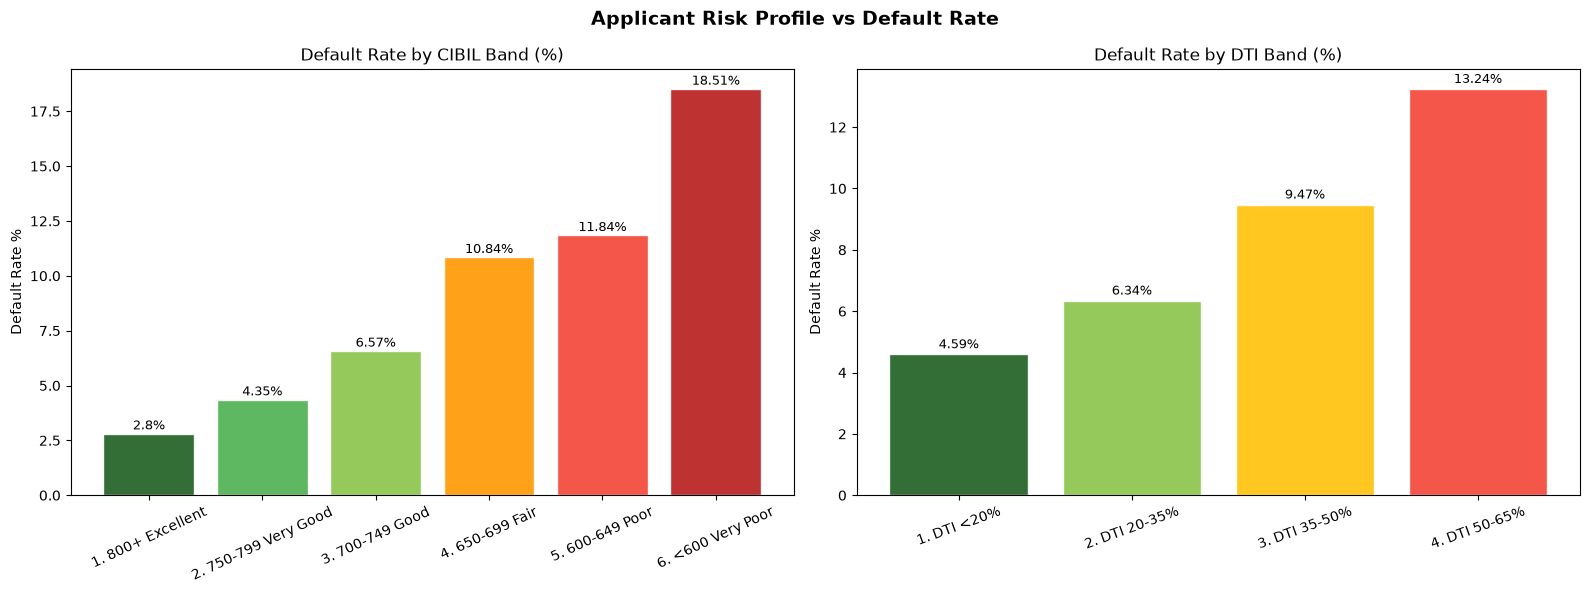

In [4]:
print("EDA SECTION 1 — APPLICANT PROFILE vs DEFAULT RATE\n")

# Query 1 — CIBIL bands
cibil_default = spark.sql("""
    SELECT
        CASE
            WHEN p.cibil_score >= 800 THEN '1. 800+ Excellent'
            WHEN p.cibil_score >= 750 THEN '2. 750-799 Very Good'
            WHEN p.cibil_score >= 700 THEN '3. 700-749 Good'
            WHEN p.cibil_score >= 650 THEN '4. 650-699 Fair'
            WHEN p.cibil_score >= 600 THEN '5. 600-649 Poor'
            ELSE                           '6. <600 Very Poor'
        END                                AS cibil_band,
        COUNT(*)                           AS loans,
        ROUND(AVG(l.is_defaulted)*100, 2) AS default_rate_pct,
        ROUND(AVG(p.monthly_income), 0)    AS avg_income,
        ROUND(AVG(p.debt_to_income_ratio)*100, 1) AS avg_dti_pct
    FROM labels l
    JOIN loans lo   ON l.loan_id     = lo.loan_id
    JOIN profiles p ON lo.customer_id = p.customer_id
    GROUP BY cibil_band
    ORDER BY cibil_band
""")

print("Default Rate by CIBIL Band:")
cibil_default.show(truncate=False)

# Query 2 — DTI bands
dti_default = spark.sql("""
    SELECT
        CASE
            WHEN p.debt_to_income_ratio < 0.20 THEN '1. DTI <20%'
            WHEN p.debt_to_income_ratio < 0.35 THEN '2. DTI 20-35%'
            WHEN p.debt_to_income_ratio < 0.50 THEN '3. DTI 35-50%'
            WHEN p.debt_to_income_ratio < 0.65 THEN '4. DTI 50-65%'
            ELSE                                    '5. DTI 65%+'
        END                                AS dti_band,
        COUNT(*)                           AS loans,
        ROUND(AVG(l.is_defaulted)*100, 2) AS default_rate_pct
    FROM labels l
    JOIN loans lo   ON l.loan_id     = lo.loan_id
    JOIN profiles p ON lo.customer_id = p.customer_id
    GROUP BY dti_band
    ORDER BY dti_band
""")

print("Default Rate by DTI Band:")
dti_default.show(truncate=False)

# Visualize
cibil_pd = cibil_default.toPandas()
dti_pd   = dti_default.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Applicant Risk Profile vs Default Rate",
             fontsize=14, fontweight="bold")

colors_c = ["#1B5E20","#4CAF50","#8BC34A",
            "#FF9800","#F44336","#B71C1C"]
axes[0].bar(
    cibil_pd["cibil_band"],
    cibil_pd["default_rate_pct"],
    color=colors_c, edgecolor="white", alpha=0.9
)
axes[0].set_title("Default Rate by CIBIL Band (%)")
axes[0].set_ylabel("Default Rate %")
axes[0].tick_params(axis="x", rotation=25)
for i, v in enumerate(cibil_pd["default_rate_pct"]):
    axes[0].text(i, v+0.2, f"{v}%", ha="center", fontsize=9)

colors_d = ["#1B5E20","#8BC34A","#FFC107","#F44336","#B71C1C"]
axes[1].bar(
    dti_pd["dti_band"],
    dti_pd["default_rate_pct"],
    color=colors_d, edgecolor="white", alpha=0.9
)
axes[1].set_title("Default Rate by DTI Band (%)")
axes[1].set_ylabel("Default Rate %")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(dti_pd["default_rate_pct"]):
    axes[1].text(i, v+0.2, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{PROCESSED}/eda_01_profile_default_rate.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 2 — LOAN CHARACTERISTICS vs DEFAULT

Default Rate by Loan Type and Amount Band:
+--------------+-----------+-----+----------------+-----------------+----------------+
|loan_type     |amount_band|loans|default_rate_pct|avg_interest_rate|avg_amount_lakhs|
+--------------+-----------+-----+----------------+-----------------+----------------+
|business_loan |1. <5L     |2    |0.0             |14.73            |4.57            |
|business_loan |2. 5-15L   |1693 |11.93           |15.76            |10.54           |
|business_loan |3. 15-30L  |2535 |11.99           |15.78            |22.32           |
|business_loan |4. 30L+    |3    |33.33           |16.28            |30.0            |
|education_loan|1. <5L     |366  |9.02            |10.5             |4.11            |
|education_loan|2. 5-15L   |2190 |6.94            |10.53            |10.02           |
|education_loan|3. 15-30L  |199  |7.04            |10.35            |15.5            |
|home_loan     |2. 5-15L   |1118 |4.11

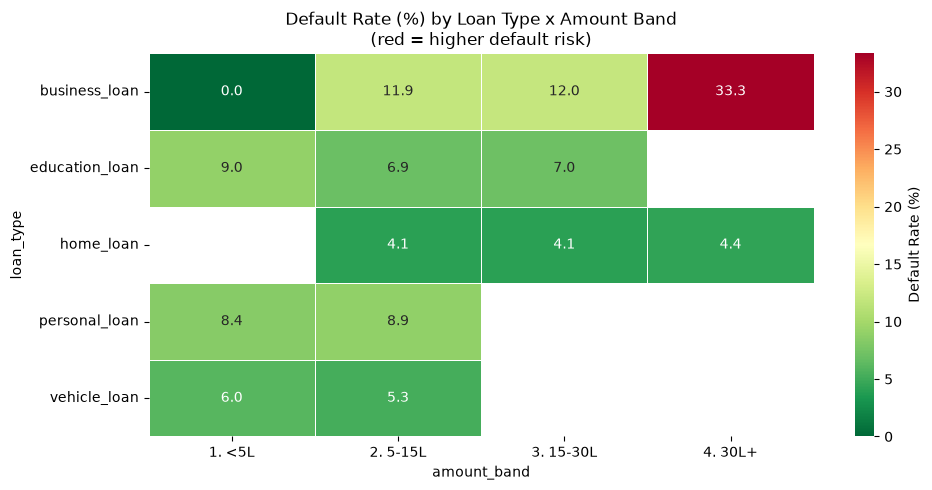

In [5]:
print("EDA SECTION 2 — LOAN CHARACTERISTICS vs DEFAULT\n")

# Loan type and amount band
loan_analysis = spark.sql("""
    SELECT
        lo.loan_type,
        CASE
            WHEN lo.loan_amount_requested < 500000
                 THEN '1. <5L'
            WHEN lo.loan_amount_requested < 1500000
                 THEN '2. 5-15L'
            WHEN lo.loan_amount_requested < 3000000
                 THEN '3. 15-30L'
            ELSE '4. 30L+'
        END                                  AS amount_band,
        COUNT(*)                             AS loans,
        ROUND(AVG(l.is_defaulted)*100, 2)   AS default_rate_pct,
        ROUND(AVG(lo.interest_rate), 2)      AS avg_interest_rate,
        ROUND(AVG(lo.loan_amount_requested) / 100000, 2) AS avg_amount_lakhs
    FROM labels l
    JOIN loans lo ON l.loan_id = lo.loan_id
    GROUP BY lo.loan_type, amount_band
    ORDER BY lo.loan_type, amount_band
""")

print("Default Rate by Loan Type and Amount Band:")
loan_analysis.show(25, truncate=False)

# Secured vs unsecured
secured_analysis = spark.sql("""
    SELECT
        lo.is_secured,
        lo.loan_type,
        COUNT(*)                             AS loans,
        ROUND(AVG(l.is_defaulted)*100, 2)   AS default_rate_pct,
        ROUND(AVG(l.lgd), 4)                AS avg_lgd,
        ROUND(AVG(l.expected_loss), 0)       AS avg_el
    FROM labels l
    JOIN loans lo ON l.loan_id = lo.loan_id
    GROUP BY lo.is_secured, lo.loan_type
    ORDER BY lo.is_secured DESC, default_rate_pct DESC
""")

print("Secured vs Unsecured Default and LGD:")
secured_analysis.show(truncate=False)

# Visualize
loan_pd = loan_analysis.toPandas()
pivot   = loan_pd.pivot_table(
    index="loan_type",
    columns="amount_band",
    values="default_rate_pct",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, annot=True, fmt=".1f",
    cmap="RdYlGn_r", ax=ax,
    linewidths=0.5,
    cbar_kws={"label": "Default Rate (%)"}
)
ax.set_title(
    "Default Rate (%) by Loan Type x Amount Band\n"
    "(red = higher default risk)",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{PROCESSED}/eda_02_loan_default_heatmap.png",
            dpi=130, bbox_inches="tight")
plt.show()

EDA SECTION 3 — DPD TRAJECTORY ANALYSIS

The most important section in this notebook.
How does Days Past Due evolve before default?



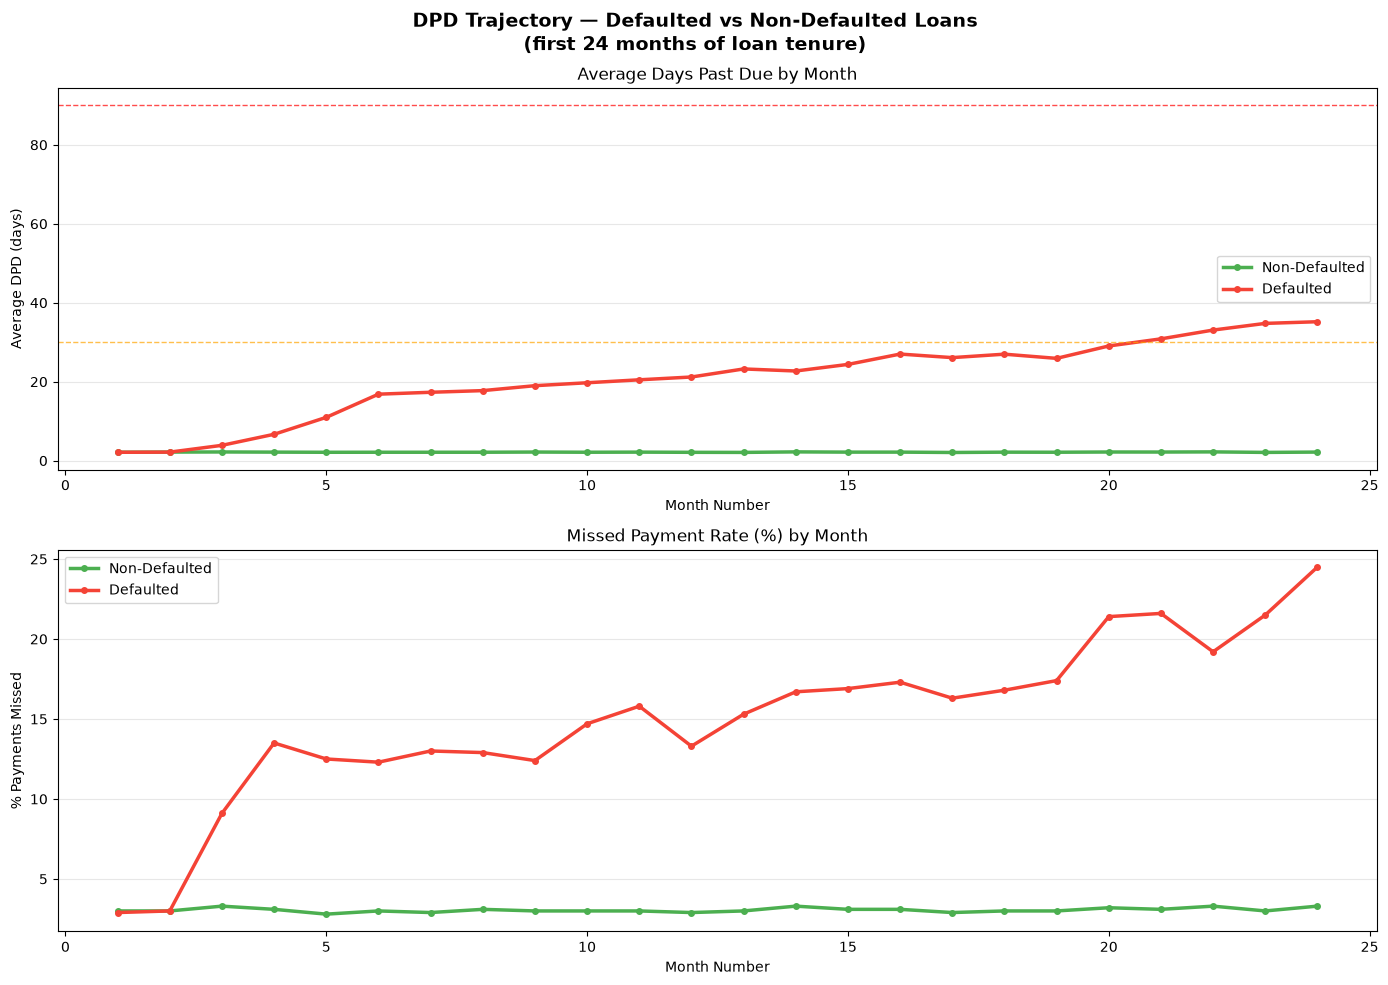


DPD comparison — months 1-6 vs 7-12:
+------------+------------+-------------+--------------+
|is_defaulted|avg_dpd_m1_6|avg_dpd_m7_12|avg_dpd_m13_24|
+------------+------------+-------------+--------------+
|           0|        2.15|         2.14|          2.15|
|           1|        7.11|         19.1|         27.01|
+------------+------------+-------------+--------------+



In [14]:
print("EDA SECTION 3 — DPD TRAJECTORY ANALYSIS\n")
print("The most important section in this notebook.")
print("How does Days Past Due evolve before default?\n")

# Average DPD by month number for defaulted vs non-defaulted
dpd_trajectory = spark.sql("""
    SELECT
        r.month_number,
        l.is_defaulted,
        ROUND(AVG(r.days_past_due), 2) AS avg_dpd,
        ROUND(AVG(CASE WHEN r.payment_status = 'missed' THEN 1.0 ELSE 0.0 END), 3) AS missed_rate,
        ROUND(AVG(r.outstanding_principal) / 100000, 2) AS avg_outstanding_lakhs
    FROM repayment r
    JOIN labels l ON r.loan_id = l.loan_id
    WHERE r.month_number <= 24
    GROUP BY r.month_number, l.is_defaulted
    ORDER BY r.month_number, l.is_defaulted
""")

dpd_pd = dpd_trajectory.toPandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(
    "DPD Trajectory — Defaulted vs Non-Defaulted Loans\n"
    "(first 24 months of loan tenure)",
    fontsize=14, fontweight="bold"
)

colors = {0: "#4CAF50", 1: "#F44336"}
labels_map = {0: "Non-Defaulted", 1: "Defaulted"}

for status in [0, 1]:
    subset = dpd_pd[dpd_pd["is_defaulted"] == status]
    axes[0].plot(
        subset["month_number"],
        subset["avg_dpd"],
        color=colors[status], linewidth=2.5,
        marker="o", markersize=4,
        label=labels_map[status]
    )

axes[0].set_title("Average Days Past Due by Month")
axes[0].set_xlabel("Month Number")
axes[0].set_ylabel("Average DPD (days)")
axes[0].legend()
axes[0].axhline(30, color="orange", linestyle="--",
                linewidth=1, alpha=0.7, label="30 DPD threshold")
axes[0].axhline(90, color="red", linestyle="--",
                linewidth=1, alpha=0.7, label="90 DPD = NPA")
axes[0].grid(axis="y", alpha=0.3)

for status in [0, 1]:
    subset = dpd_pd[dpd_pd["is_defaulted"] == status]
    axes[1].plot(
        subset["month_number"],
        subset["missed_rate"] * 100,
        color=colors[status], linewidth=2.5,
        marker="o", markersize=4,
        label=labels_map[status]
    )

axes[1].set_title("Missed Payment Rate (%) by Month")
axes[1].set_xlabel("Month Number")
axes[1].set_ylabel("% Payments Missed")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED}/eda_03_dpd_trajectory.png",
            dpi=130, bbox_inches="tight")
plt.show()

print("\nDPD comparison — months 1-6 vs 7-12:")

# Guard for standalone execution: this cell should still work if run without
# the earlier setup cells in the notebook.
if (
    "spark" not in globals()
    or "labels" not in globals()
    or "repayment" not in globals()
    or not spark.catalog.tableExists("labels")
    or not spark.catalog.tableExists("repayment")
):
    from pyspark.sql import SparkSession
    from pathlib import Path
    import os

    current = Path.cwd()
    project_dir = next(
        (
            candidate
            for candidate in [current, *current.parents]
            if (candidate / "data" / "processed").exists() and (candidate / "jars").exists()
        ),
        current,
    )

    os.environ["HADOOP_HOME"] = r"C:\hadoop"
    os.environ["PATH"] = r"C:\hadoop\bin;" + os.environ["PATH"]

    JAR_PATH = str((project_dir / "jars" / "sqlite-jdbc-3.45.1.0.jar").resolve())
    PROCESSED = str((project_dir / "data" / "processed").resolve())
    LOCAL_TEMP = str((project_dir / "data" / "spark_temp").resolve())

    spark = (
        SparkSession.builder
        .appName("LoanDefault_EDA_cell_5_guard")
        .master("local[2]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.driver.extraClassPath", JAR_PATH)
        .config("spark.executor.extraClassPath", JAR_PATH)
        .config("spark.local.dir", LOCAL_TEMP)
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")

    labels = spark.read.option("header", "true") \
        .option("inferSchema", "true") \
        .csv(f"{PROCESSED}/labels_clean.csv")
    repayment = spark.read.option("header", "true") \
        .option("inferSchema", "true") \
        .csv(f"{PROCESSED}/repayment_clean.csv")

    labels.createOrReplaceTempView("labels")
    repayment.createOrReplaceTempView("repayment")

spark.sql("""
    SELECT
        l.is_defaulted,
        ROUND(AVG(CASE WHEN r.month_number <= 6
                       THEN r.days_past_due END), 2) AS avg_dpd_m1_6,
        ROUND(AVG(CASE WHEN r.month_number BETWEEN 7 AND 12
                       THEN r.days_past_due END), 2) AS avg_dpd_m7_12,
        ROUND(AVG(CASE WHEN r.month_number BETWEEN 13 AND 24
                       THEN r.days_past_due END), 2) AS avg_dpd_m13_24
    FROM repayment r
    JOIN labels l ON r.loan_id = l.loan_id
    GROUP BY l.is_defaulted
    ORDER BY l.is_defaulted
""").show()

EDA SECTION 4 — FEATURE CORRELATION FOUNDATION

Building applicant-level feature summary for correlation

Feature Correlations with is_defaulted:

Rank  Feature                       |Correlation|
--------------------------------------------------
  1   max_dpd                        0.9421  █████████████████████████████████████ ← STRONG
  2   avg_dpd                        0.8606  ██████████████████████████████████ ← STRONG
  3   on_time_rate                   0.6333  █████████████████████████ ← STRONG
  4   missed_count                   0.3640  ██████████████ ← STRONG
  5   late_count                     0.2464  █████████
  6   cibil_score                    0.1535  ██████
  7   debt_to_income_ratio           0.0984  ███
  8   is_secured                     0.0901  ███
  9   interest_rate                  0.0858  ███
  10  has_credit_history             0.0751  ███
  11  ltv_ratio                      0.0662  ██
  12  tenure_months                  0.0604  ██
  13  loan_amount_reque

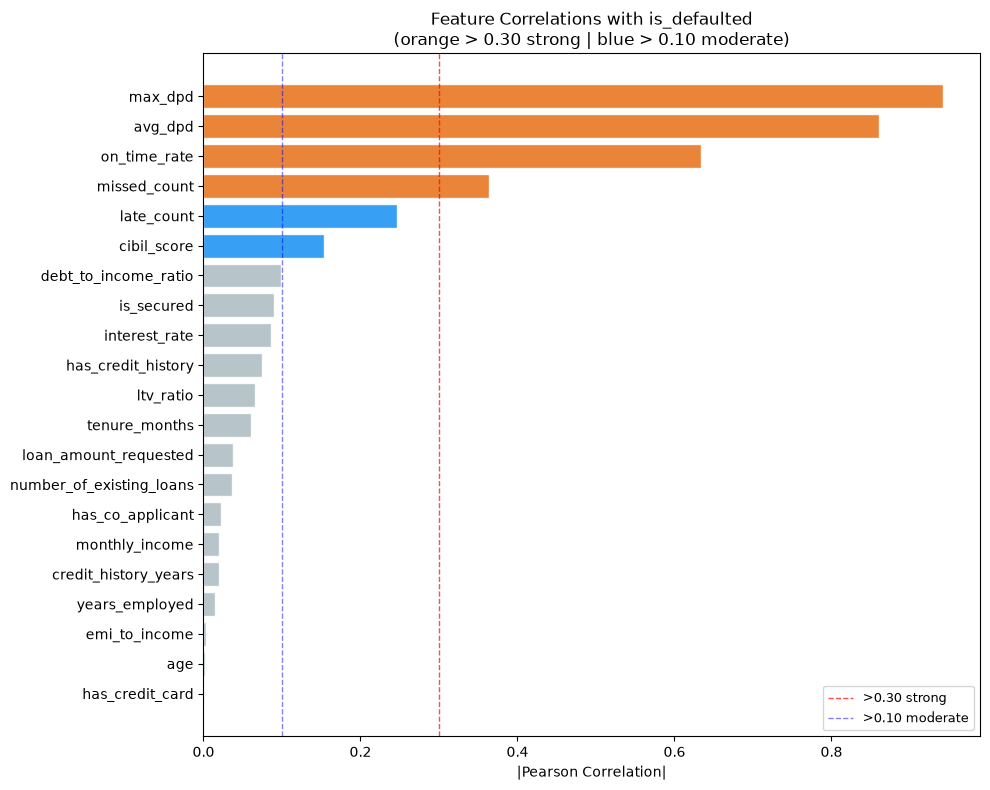


Cache cleared ✅


In [16]:
print("EDA SECTION 4 — FEATURE CORRELATION FOUNDATION\n")
print("Building applicant-level feature summary for correlation\n")

# Build a preview of what Feature Engineering will compute
customer_features = spark.sql("""
    SELECT
        l.loan_id,
        l.is_defaulted,
        l.expected_loss,

        -- Applicant static features
        p.cibil_score,
        p.monthly_income,
        p.debt_to_income_ratio,
        p.age,
        p.years_employed,
        p.number_of_existing_loans,
        p.credit_history_years,
        p.has_credit_history,
        p.has_co_applicant,
        p.has_credit_card,

        -- Loan features
        lo.loan_amount_requested,
        lo.interest_rate,
        lo.tenure_months,
        lo.is_secured,
        lo.ltv_ratio,

        -- Computed: EMI to income ratio
        ROUND(lo.emi_amount / (p.monthly_income + 1), 4)
                                             AS emi_to_income,

        -- Repayment behavior (aggregate)
        r.avg_dpd,
        r.max_dpd,
        r.missed_count,
        r.late_count,
        r.on_time_rate

    FROM labels l
    JOIN loans lo ON l.loan_id = lo.loan_id
    JOIN profiles p ON lo.customer_id = p.customer_id
    JOIN (
        SELECT
            loan_id,
            ROUND(AVG(days_past_due), 2) AS avg_dpd,
            MAX(days_past_due) AS max_dpd,
            SUM(CASE WHEN payment_status = 'missed' THEN 1 ELSE 0 END) AS missed_count,
            SUM(CASE WHEN payment_status IN ('late', 'partial') THEN 1 ELSE 0 END) AS late_count,
            ROUND(AVG(CASE WHEN payment_status = 'on_time' THEN 1.0 ELSE 0.0 END), 4) AS on_time_rate
        FROM repayment
        GROUP BY loan_id
    ) r ON l.loan_id = r.loan_id
""")

# Collect to pandas for correlation
feat_pd = customer_features.toPandas()
feat_pd["is_secured"] = feat_pd["is_secured"].astype(int)
feat_pd["has_co_applicant"] = feat_pd["has_co_applicant"].astype(int)
feat_pd["has_credit_card"]  = feat_pd["has_credit_card"].astype(int)

numeric_cols = [
    "cibil_score","monthly_income","debt_to_income_ratio",
    "age","years_employed","number_of_existing_loans",
    "credit_history_years","has_credit_history","has_co_applicant",
    "has_credit_card","loan_amount_requested","interest_rate",
    "tenure_months","is_secured","ltv_ratio","emi_to_income",
    "avg_dpd","max_dpd","missed_count","late_count","on_time_rate"
]

correlations = (
    feat_pd[numeric_cols + ["is_defaulted"]]
    .corr()["is_defaulted"]
    .drop("is_defaulted")
    .abs()
    .sort_values(ascending=False)
)

print("Feature Correlations with is_defaulted:")
print(f"\n{'Rank':<5} {'Feature':<28} {'|Correlation|':>14}")
print("-" * 50)
for i, (feat, val) in enumerate(correlations.items(), 1):
    bar   = "█" * int(val * 40)
    flag  = " ← STRONG" if val > 0.30 else ""
    print(f"  {i:<3} {feat:<28} {val:>8.4f}  {bar}{flag}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
colors  = [
    "#E87722" if v > 0.30 else
    "#2196F3" if v > 0.10 else
    "#B0BEC5"
    for v in correlations.values
]
ax.barh(correlations.index, correlations.values,
        color=colors, edgecolor="white", alpha=0.9)
ax.set_title(
    "Feature Correlations with is_defaulted\n"
    "(orange > 0.30 strong | blue > 0.10 moderate)",
    fontsize=12
)
ax.set_xlabel("|Pearson Correlation|")
ax.axvline(0.30, color="red", linestyle="--",
           linewidth=1, alpha=0.7, label=">0.30 strong")
ax.axvline(0.10, color="blue", linestyle="--",
           linewidth=1, alpha=0.5, label=">0.10 moderate")
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{PROCESSED}/eda_04_feature_correlations.png",
            dpi=130, bbox_inches="tight")
plt.show()

# Cleanup
repayment.unpersist()
print("\nCache cleared ✅")

In [1]:

print("=" * 65)
print(" EDA COMPLETE — KEY FINDINGS")
print("=" * 65)

print(f"""
CIBIL SCORE FINDINGS
  Highest default rate  : 18.51% at CIBIL <600
  Lowest default rate   : 2.80% at CIBIL 800+
  Range                 : 6.61x difference
  Absolute gap          : 15.71 percentage points

DTI FINDINGS
  DTI <20% default rate : 4.59%
  DTI 50-65% default rate : 13.24%
  Default rate increases with higher DTI.

DPD TRAJECTORY (Critical Finding)
  Non-defaulted avg DPD months 1-6  : 2.15
  Defaulted avg DPD months 1-6      : 7.11
  Non-defaulted avg DPD months 7-12 : 2.14
  Defaulted avg DPD months 7-12     : 19.10
  Defaulted avg DPD months 13-24    : 27.01

  Early warning window:
  Elevated DPD is already visible in months 1-6.
  Exact months before NPA require event-level validation.

TOP CORRELATED FEATURES
  Rank 1 : max_dpd       (corr=0.9421)
  Rank 2 : avg_dpd       (corr=0.8606)
  Rank 3 : on_time_rate  (corr=0.6333)
  Rank 4 : missed_count  (corr=0.3640)
  Rank 5 : late_count    (corr=0.2464)

FEATURE ENGINEERING PRIORITIES
  1. max_dpd         — worst observed payment delinquency
  2. avg_dpd         — average repayment delinquency
  3. on_time_rate    — payment consistency
  4. missed_count    — total missed payments
  5. late_count      — frequency of late payments
  6. cibil_score     — credit profile
  7. emi_to_income   — payment burden ratio
  8. debt_to_income  — overall leverage
  9. is_secured      — collateral presence

KEY BUSINESS INSIGHT
  Repayment behavior features demonstrate stronger
  correlation with default than most applicant-level
  demographic and financial features.

  DPD trajectory provides a potential early-warning
  signal for credit risk assessment.

NEXT STEP
  Proceed to feature engineering and model development.
""")

print("=" * 65)
print(" EDA SECTION COMPLETED SUCCESSFULLY")
print("=" * 65)


 EDA COMPLETE — KEY FINDINGS

CIBIL SCORE FINDINGS
  Highest default rate  : 18.51% at CIBIL <600
  Lowest default rate   : 2.80% at CIBIL 800+
  Range                 : 6.61x difference
  Absolute gap          : 15.71 percentage points

DTI FINDINGS
  DTI <20% default rate : 4.59%
  DTI 50-65% default rate : 13.24%
  Default rate increases with higher DTI.

DPD TRAJECTORY (Critical Finding)
  Non-defaulted avg DPD months 1-6  : 2.15
  Defaulted avg DPD months 1-6      : 7.11
  Non-defaulted avg DPD months 7-12 : 2.14
  Defaulted avg DPD months 7-12     : 19.10
  Defaulted avg DPD months 13-24    : 27.01

  Early warning window:
  Elevated DPD is already visible in months 1-6.
  Exact months before NPA require event-level validation.

TOP CORRELATED FEATURES
  Rank 1 : max_dpd       (corr=0.9421)
  Rank 2 : avg_dpd       (corr=0.8606)
  Rank 3 : on_time_rate  (corr=0.6333)
  Rank 4 : missed_count  (corr=0.3640)
  Rank 5 : late_count    (corr=0.2464)

FEATURE ENGINEERING PRIORITIES
  1.